In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp
import scipy.sparse.linalg as spla

#Plot styling
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['lines.linewidth'] = 3


In [8]:
#Global parameters
xmin, xmax = 0, 5
n = 100

#Dense, log-spaced sequence of grid sizes for a smooth convergence curve
n_values = np.unique(np.round(np.geomspace(25, 800, 13)).astype(int))


In [9]:
#Exact solution / forcing function, and the linear system builder
def u_exact(x):
    return np.sin(x)

def f_exact(x):
    # u'' + sin(x) u' + u for u(x) = sin(x): -sin(x) + sin(x)cos(x) + sin(x) = sin(x)cos(x)
    return np.sin(x) * np.cos(x)

def build_system(n):
    h = (xmax - xmin) / (n - 1)
    x = np.linspace(xmin, xmax, n)

    a_i = 1 / h**2 - np.sin(x) / (2 * h)   # sub-diagonal, coefficient of u_{i-1}
    b_i = -2 / h**2 + 1                    # main diagonal, coefficient of u_i
    c_i = 1 / h**2 + np.sin(x) / (2 * h)   # super-diagonal, coefficient of u_{i+1}

    row, col, val = [], [], []

    #Dirichlet rows: u_0 = u(xmin), u_{n-1} = u(xmax)
    row.append(0); col.append(0); val.append(1.0)
    row.append(n - 1); col.append(n - 1); val.append(1.0)

    for i in range(1, n - 1):
        row.append(i); col.append(i - 1); val.append(a_i[i])
        row.append(i); col.append(i);     val.append(b_i)
        row.append(i); col.append(i + 1); val.append(c_i[i])

    A = sp.coo_matrix((val, (row, col)), shape=(n, n)).tocsc()

    rhs = f_exact(x)
    rhs[0] = u_exact(xmin)
    rhs[-1] = u_exact(xmax)

    return x, A, rhs


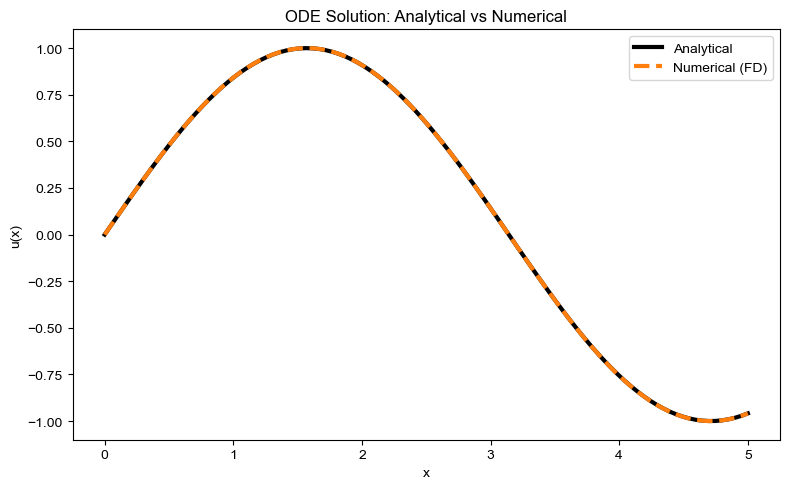

In [10]:
#Solve on the base grid and compare to the analytical solution
x, A, rhs = build_system(n)
u_num = spla.spsolve(A, rhs)

plt.figure(figsize=(8, 5))
plt.plot(x, u_exact(x), label="Analytical", color="black")
plt.plot(x, u_num, "--", label="Numerical (FD)", color="tab:orange")
plt.xlabel("x")
plt.ylabel("u(x)")
plt.title("ODE Solution: Analytical vs Numerical")
plt.legend()
plt.tight_layout()
plt.savefig("figures/problem3_solution_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


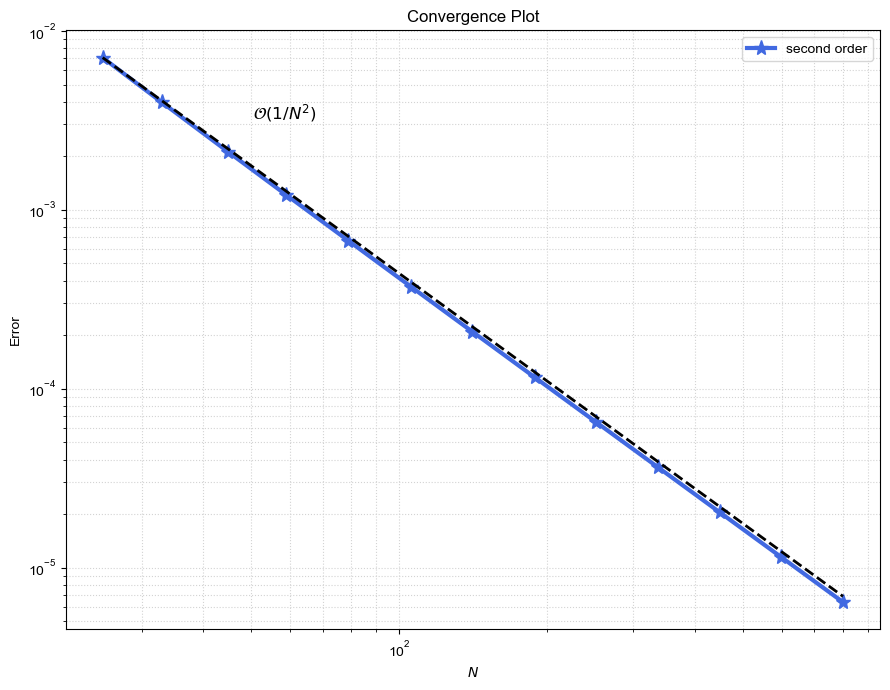

In [11]:
#Convergence study: L2 relative error vs grid size N
error_l2 = []

for nn in n_values:
    xn, An, rhsn = build_system(nn)
    un = spla.spsolve(An, rhsn)
    exact = u_exact(xn)
    err = un - exact

    error_l2.append(np.linalg.norm(err, ord=2) / np.linalg.norm(exact, ord=2))

error_l2 = np.array(error_l2)
reference = error_l2[0] * (n_values[0] / n_values) ** 2

fig, ax = plt.subplots(figsize=(9, 7))

ax.loglog(n_values, error_l2, "*-", color="royalblue", markersize=11, label="second order")
ax.loglog(n_values, reference, "--", color="black", linewidth=2)

#Annotate the reference slope directly on the plot, offset into open space above the line
anchor = 2
ax.annotate(
    r"$\mathcal{O}(1/N^2)$",
    xy=(n_values[anchor], reference[anchor]),
    xytext=(18, 22),
    textcoords="offset points",
    fontsize=12,
)

ax.set_xlabel(r"$N$")
ax.set_ylabel("Error")
ax.set_title("Convergence Plot")
ax.grid(True, which="both", linestyle=":", color="lightgray")
ax.legend(loc="upper right", frameon=True)

plt.tight_layout()
plt.savefig("figures/problem3_convergence.png", dpi=150, bbox_inches="tight")
plt.show()
